# 02 — Habitudes alimentaires & scores de santé

Ce notebook est le cœur quantitatif de l'analyse. On y décrit **ce que les gens
mangent** (fréquences de consommation), on construit un **Score Santé** synthétique, puis
on teste de façon approfondie **qui mange le mieux** : différences selon le sexe, le
territoire, le niveau d'étude et la profession, avec tailles d'effet, tests post-hoc et
un modèle de régression pour démêler les facteurs confondus.

Rappel du notebook 01 : l'échantillon est jeune, féminin, urbain et diplômé — les
résultats valent d'abord *au sein de cet échantillon*.

## 1. Préparation

On charge les données nettoyées (mêmes fonctions que l'application) et la librairie
`pingouin` pour les tests statistiques, `statsmodels` pour la régression.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pingouin as pg
import statsmodels.formula.api as smf
from IPython.display import display, Markdown

from utils.data_loader import load_data, clean_data, get_questions_dict

sns.set_theme(style="whitegrid", palette="muted")
q = get_questions_dict()
df = clean_data(load_data())
print(f"{df.shape[0]} répondants chargés")

1681 répondants chargés


## 2. Fréquences de consommation par aliment

Pour chaque famille d'aliments, on calcule la répartition des fréquences déclarées (en %
de répondants), de « Jamais » à « À tous les repas ». La heatmap se lit en ligne.

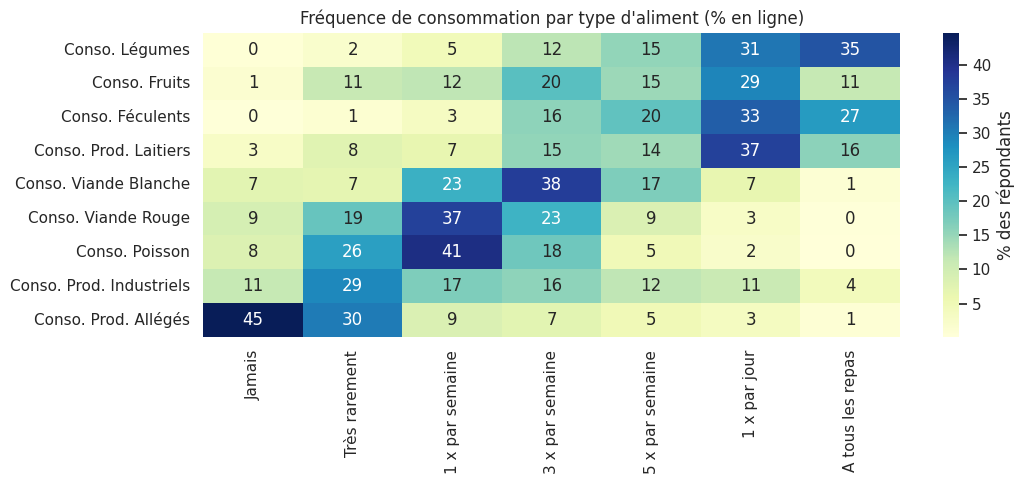

In [2]:
FREQ_ORDER = ["Jamais", "Très rarement", "1 x par semaine", "3 x par semaine",
              "5 x par semaine", "1 x par jour", "A tous les repas"]
conso_cols = [c for c in df.columns if c.startswith("C_") and not c.endswith("_num")]

heat = pd.DataFrame([
    (df[c].value_counts(normalize=True).reindex(FREQ_ORDER) * 100).rename(q.get(c, c))
    for c in conso_cols
])
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label": "% des répondants"}, ax=ax)
ax.set_title("Fréquence de consommation par type d'aliment (% en ligne)")
ax.set_xlabel(""); ax.set_ylabel("")
fig.tight_layout()

Deux blocs se dégagent nettement. Les **légumes, fruits, féculents et produits laitiers**
sont consommés quotidiennement par une large majorité (35 % mangent des légumes à *tous
les repas*). À l'inverse, **viande rouge, poisson, produits industriels et allégés** sont
rares : la viande rouge ne dépasse jamais « 1 fois par jour » que pour 3 % des répondants,
et 45 % ne consomment **jamais** de produits allégés. On a donc une population qui se
déclare plutôt « végétale et fraîche » — déclaratif à prendre avec la prudence d'usage.

## 3. Des fréquences aux scores de santé

Les fréquences textuelles sont converties en une échelle numérique hebdomadaire
(`Jamais`=0, `1 x par semaine`=1, …, `À tous les repas`=14). Deux scores synthétiques en
découlent (définis dans `utils/data_loader.py`) :

- **Score Santé** = Légumes + Fruits + Poisson − Produits industriels ;
- **Score Carné** = Viande rouge + Viande blanche.

*Limite assumée* : avant calcul, les valeurs manquantes des composantes sont remplacées
par la médiane de la colonne ; le score n'est donc pas un manquant-robuste, et sa valeur
absolue n'a pas de sens « clinique ». Il sert de **mesure relative** pour comparer des
sous-groupes, ce qui est précisément notre usage ici.

In [3]:
scores = (df[["Score_Sante", "Score_Carné"]]
          .describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(1))
display(Markdown(scores.to_markdown()))

|             |   mean |   std |   min |   25% |   50% |   75% |   max |
|:------------|-------:|------:|------:|------:|------:|------:|------:|
| Score_Sante |   12.1 |   9   |   -14 |     6 |    12 |    19 |  41.5 |
| Score_Carné |    4.7 |   3.4 |     0 |     2 |     4 |     6 |  28   |

Le Score Santé s'étale de −14 à +41 (moyenne 12,1). Cette dispersion large est une bonne
nouvelle : le score discrimine suffisamment les profils pour que les comparaisons de
groupes aient du sens.

## 4. Distribution du Score Santé

On visualise la distribution avant de la soumettre aux tests.

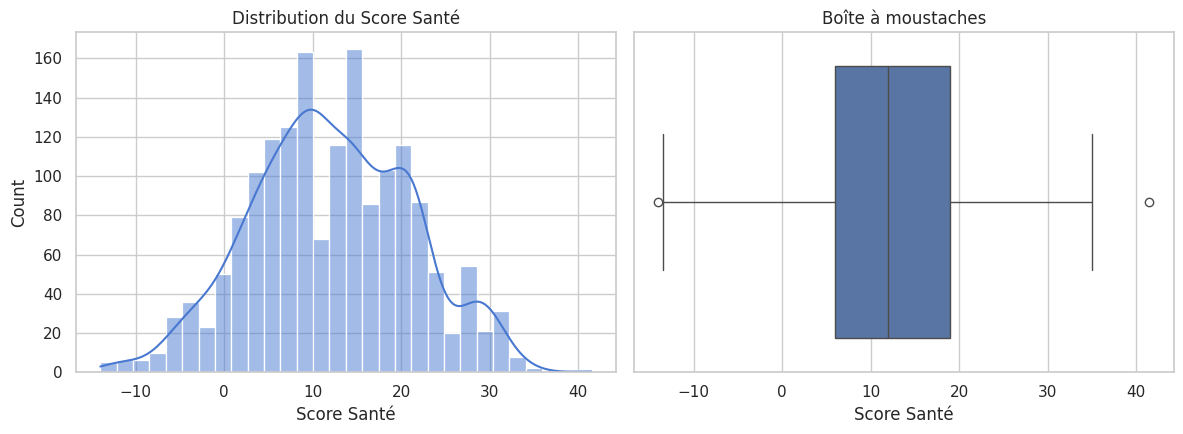

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["Score_Sante"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution du Score Santé"); axes[0].set_xlabel("Score Santé")
sns.boxplot(x=df["Score_Sante"], ax=axes[1], color="#4C72B0")
axes[1].set_title("Boîte à moustaches"); axes[1].set_xlabel("Score Santé")
fig.tight_layout()

La distribution est unimodale, centrée autour de 12, légèrement asymétrique. Le test de
**Shapiro-Wilk rejette la normalité** (p < 0,001) — attendu sur 1 681 observations où le
moindre écart devient significatif. Par prudence, on privilégie pour la suite des tests
**robustes à l'hétéroscédasticité et à la non-normalité** (t de Welch, ANOVA de Welch,
post-hoc de Games-Howell).

## 5. Le score varie-t-il selon le sexe et le territoire ?

Comparaisons à deux groupes : **t-test de Welch**, avec taille d'effet (*d* de Cohen) et
intervalle de confiance à 95 % de la différence.

| Facteur   |   Femme (moy.) |   Homme (moy.) |   p-val |   d de Cohen | IC95% diff.   |   Rural (moy.) |   Citad (moy.) |
|:----------|---------------:|---------------:|--------:|-------------:|:--------------|---------------:|---------------:|
| Sexe      |          12.37 |          11.52 |   0.085 |        0.094 | [-0.12, 1.81] |         nan    |         nan    |
| Rura      |         nan    |         nan    |   0.06  |        0.094 | [-0.04, 1.74] |          12.66 |          11.81 |

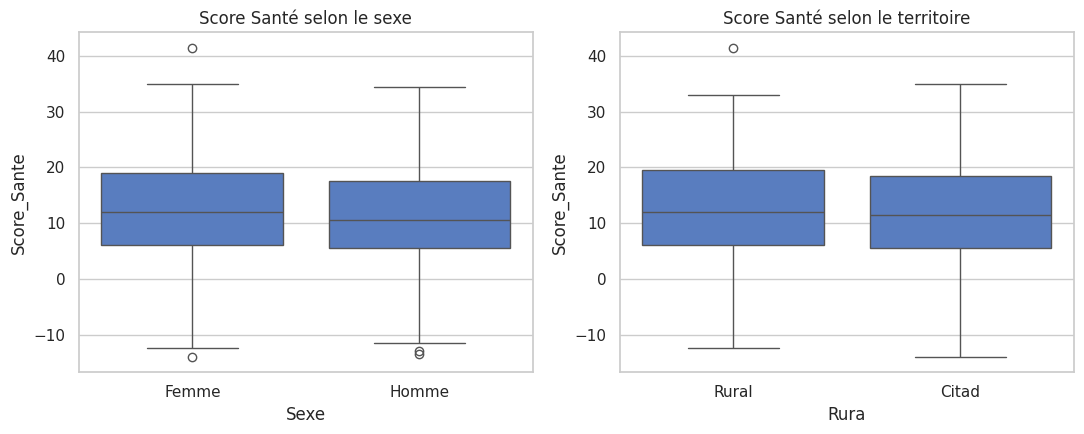

In [5]:
def ttest_row(fac):
    g = df[fac].dropna().unique()
    x = df.loc[df[fac] == g[0], "Score_Sante"]
    y = df.loc[df[fac] == g[1], "Score_Sante"]
    r = pg.ttest(x, y, correction=True).iloc[0]
    return {"Facteur": fac, f"{g[0]} (moy.)": round(x.mean(), 2),
            f"{g[1]} (moy.)": round(y.mean(), 2), "p-val": round(r["p-val"], 3),
            "d de Cohen": round(r["cohen-d"], 3),
            "IC95% diff.": f"[{r['CI95%'][0]:.2f}, {r['CI95%'][1]:.2f}]"}

res = pd.DataFrame([ttest_row("Sexe"), ttest_row("Rura")])
display(Markdown(res.to_markdown(index=False)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=df, x="Sexe", y="Score_Sante", ax=axes[0]); axes[0].set_title("Score Santé selon le sexe")
sns.boxplot(data=df, x="Rura", y="Score_Sante", ax=axes[1]); axes[1].set_title("Score Santé selon le territoire")
fig.tight_layout()

Surprise : **ni le sexe ni le territoire ne produisent de différence significative**
(p = 0,085 et p = 0,06) et les tailles d'effet sont négligeables (*d* ≈ 0,09). L'idée reçue
« les femmes / les ruraux mangent mieux » ne se vérifie pas ici à l'échelle brute. On verra
au § 8 que le sexe ressort *une fois l'âge contrôlé* — un effet réel mais masqué.

## 6. Le score selon la position sociale (éducation, profession)

Comparaisons à plus de deux groupes. On vérifie d'abord l'homogénéité des variances
(**Levene**), puis on applique l'**ANOVA de Welch** (robuste), la taille d'effet η²
(*partial eta-squared*) et le post-hoc de **Games-Howell** (paires significatives).

| Facteur   |   Levene p |   Welch F |   p-val |   η² (np2) |
|:----------|-----------:|----------:|--------:|-----------:|
| Etud      |      0.462 |       6   | 0.00053 |      0.011 |
| pro       |      0.331 |      10.4 | 5.4e-10 |      0.04  |

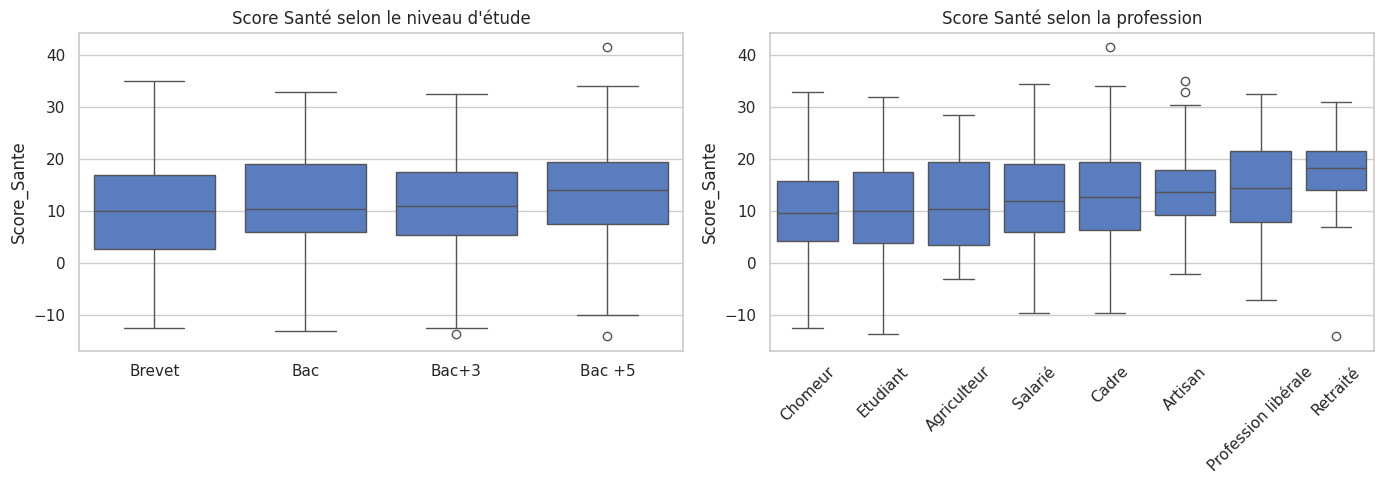

In [6]:
def anova_block(fac):
    sub = df[[fac, "Score_Sante"]].dropna()
    lev = pg.homoscedasticity(sub, dv="Score_Sante", group=fac)["pval"].values[0]
    wa = pg.welch_anova(sub, dv="Score_Sante", between=fac).iloc[0]
    np2 = pg.anova(sub, dv="Score_Sante", between=fac, detailed=True).loc[0, "np2"]
    return {"Facteur": fac, "Levene p": round(lev, 3), "Welch F": round(wa["F"], 2),
            "p-val": f"{wa['p-unc']:.1e}", "η² (np2)": round(np2, 3)}

summary = pd.DataFrame([anova_block("Etud"), anova_block("pro")])
display(Markdown(summary.to_markdown(index=False)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order_etud = ["Brevet", "Bac", "Bac+3", "Bac +5"]
sns.boxplot(data=df, x="Etud", y="Score_Sante", order=[e for e in order_etud if e in df["Etud"].unique()], ax=axes[0])
axes[0].set_title("Score Santé selon le niveau d'étude"); axes[0].set_xlabel("")
order_pro = df.groupby("pro", observed=True)["Score_Sante"].mean().sort_values().index
sns.boxplot(data=df, x="pro", y="Score_Sante", order=order_pro, ax=axes[1])
axes[1].set_title("Score Santé selon la profession"); axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()

Les paires de professions significativement différentes (Games-Howell) :

In [7]:
gh = pg.pairwise_gameshowell(df[["pro", "Score_Sante"]].dropna(), dv="Score_Sante", between="pro")
gh_sig = (gh[gh["pval"] < 0.05][["A", "B", "diff", "pval", "hedges"]]
          .sort_values("pval").round(3).rename(columns={"hedges": "g de Hedges"}))
display(Markdown(gh_sig.to_markdown(index=False)))

| A        | B                   |   diff |   pval |   g de Hedges |
|:---------|:--------------------|-------:|-------:|--------------:|
| Etudiant | Retraité            | -7.529 |  0     |        -0.835 |
| Etudiant | Profession libérale | -4.426 |  0     |        -0.489 |
| Chomeur  | Retraité            | -8.243 |  0     |        -0.902 |
| Retraité | Salarié             |  5.576 |  0     |         0.653 |
| Cadre    | Etudiant            |  3.025 |  0.001 |         0.332 |
| Cadre    | Retraité            | -4.504 |  0.004 |        -0.515 |
| Etudiant | Salarié             | -1.953 |  0.006 |        -0.22  |
| Chomeur  | Profession libérale | -5.141 |  0.01  |        -0.559 |

Les deux facteurs sont significatifs, mais d'ampleur modeste : l'éducation explique à peine
1 % de la variance (η² = 0,011 ; seul **Bac+5** se détache vers le haut), la profession
davantage (η² = 0,040). Le classement professionnel est éloquent : **retraités** (17,8) et
**professions libérales** (14,7) en tête, **chômeurs** (9,6) et **étudiants** (10,3) en bas.
Mais « retraité » est largement un proxy de l'âge — d'où la nécessité d'un modèle
multivarié.

## 7. Quelles consommations vont ensemble ?

Corrélations de **Spearman** (adaptées aux échelles ordinales) entre les fréquences
numériques de consommation.

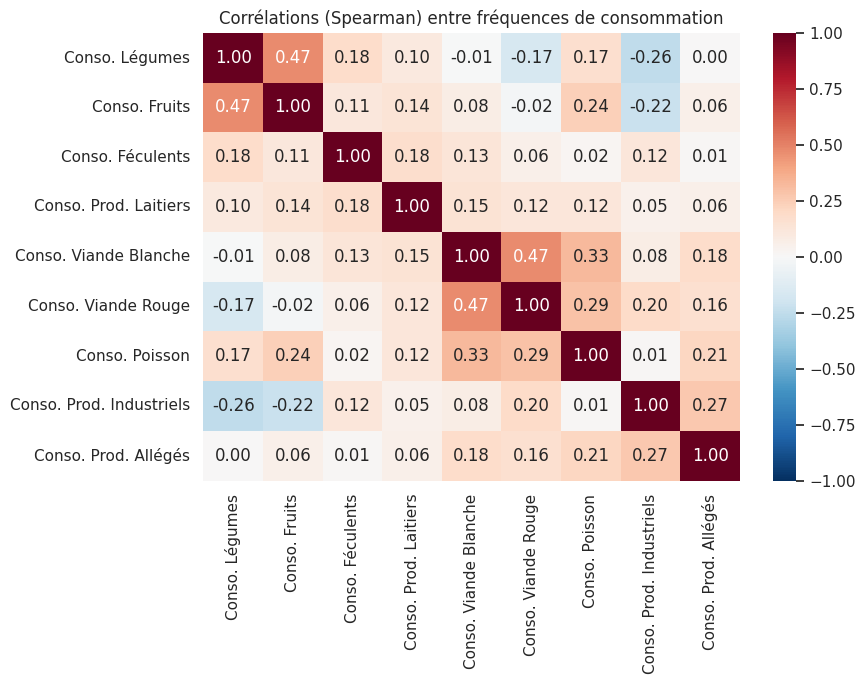

In [8]:
num_cols = [c for c in df.columns if c.endswith("_num")]
labels = {c: q.get(c[:-4], c) for c in num_cols}
corr = df[num_cols].rename(columns=labels).corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Corrélations (Spearman) entre fréquences de consommation")
fig.tight_layout()

La structure dessine deux « mondes » alimentaires cohérents : **fruits ↔ légumes**
(ρ = 0,47) d'un côté, **viande rouge ↔ viande blanche** (ρ = 0,47) de l'autre. Surtout, les
**produits industriels sont négativement corrélés aux légumes et aux fruits** (ρ ≈ −0,26 et
−0,22) : manger frais et manger industriel s'excluent partiellement — l'opposition de fond
que l'ACM du notebook 03 va spatialiser.

## 8. Modèle explicatif : régression du Score Santé

Pour démêler les effets confondus (la profession « retraité » porte de l'âge, etc.), on
régresse le Score Santé sur le sexe, l'âge, le niveau d'étude et le territoire
(**OLS**, modalités de référence : Femme, +60 ans, Bac, Citadin).

In [9]:
model = smf.ols("Score_Sante ~ C(Sexe) + C(Age) + C(Etud) + C(Rura)", data=df).fit()
coef = pd.DataFrame({
    "coef.": model.params, "p-val": model.pvalues,
    "IC 2.5%": model.conf_int()[0], "IC 97.5%": model.conf_int()[1],
}).round(3)
display(Markdown(coef.to_markdown()))
display(Markdown(f"**R² = {model.rsquared:.3f}** (R² ajusté = {model.rsquared_adj:.3f}) — "
                 f"modèle globalement significatif (p = {model.f_pvalue:.1e})."))

|                   |   coef. |   p-val |   IC 2.5% |   IC 97.5% |
|:------------------|--------:|--------:|----------:|-----------:|
| Intercept         |  18.906 |   0     |    16.561 |     21.252 |
| C(Sexe)[T.Homme]  |  -1.049 |   0.028 |    -1.986 |     -0.112 |
| C(Age)[T.-18]     |  -9.898 |   0.014 |   -17.82  |     -1.977 |
| C(Age)[T.18-34]   |  -9.367 |   0     |   -11.589 |     -7.145 |
| C(Age)[T.35-60]   |  -4.82  |   0     |    -7.045 |     -2.595 |
| C(Etud)[T.Bac +5] |   3.143 |   0     |     1.975 |      4.311 |
| C(Etud)[T.Bac+3]  |   0.551 |   0.325 |    -0.548 |      1.65  |
| C(Etud)[T.Brevet] |  -3.143 |   0.003 |    -5.216 |     -1.071 |
| C(Rura)[T.Rural]  |  -0.01  |   0.982 |    -0.919 |      0.898 |

**R² = 0.088** (R² ajusté = 0.084) — modèle globalement significatif (p = 2.6e-29).

Le modèle n'explique que **≈ 9 % de la variance** : les déterminants socio-démographiques
ne font qu'une petite partie de l'histoire. Mais il clarifie les rôles :

- **L'âge domine** — par rapport aux 60 ans et plus, les 18-34 ans ont un score inférieur de
  ~9 points (p < 0,001). C'est *lui* qui portait l'effet « retraité » du § 6.
- **L'éducation** joue à la marge mais réellement : **Bac+5** +3,1 pts, **Brevet** −3,1 pts.
- **Le sexe** devient significatif une fois l'âge neutralisé : les hommes −1,0 pt
  (p = 0,028) — l'effet existait, masqué par la structure d'âge différente des deux sexes.
- **Le territoire** (rural/citadin) reste **sans effet** (p = 0,98).

## 9. Synthèse

**Ce que mangent les répondants.** Une alimentation déclarée à dominante végétale et
fraîche (légumes/fruits/féculents quotidiens), une viande rouge et des produits industriels
peu fréquents, des produits allégés massivement délaissés.

**Qui mange le mieux ?** Les écarts existent mais sont **modestes** :

- pas de différence brute selon le **sexe** ni le **territoire** ;
- un gradient **éducatif** faible (Bac+5 au-dessus) et **professionnel** plus net, mais ce
  dernier reflète surtout l'**âge** ;
- toutes variables socio confondues, **l'âge est le premier déterminant** (les plus jeunes
  ont les scores les plus bas), devant l'éducation puis un léger effet de sexe.

**Limite de fond.** Le modèle n'explique que ~9 % de la variance : l'essentiel des
différences de score se joue **ailleurs** que dans le socio-démographique — sans doute du
côté des goûts, des contraintes et des **croyances**, qu'on aborde aux notebooks 03 (espace
social, ACM) et 04 (croyances vs pratiques).